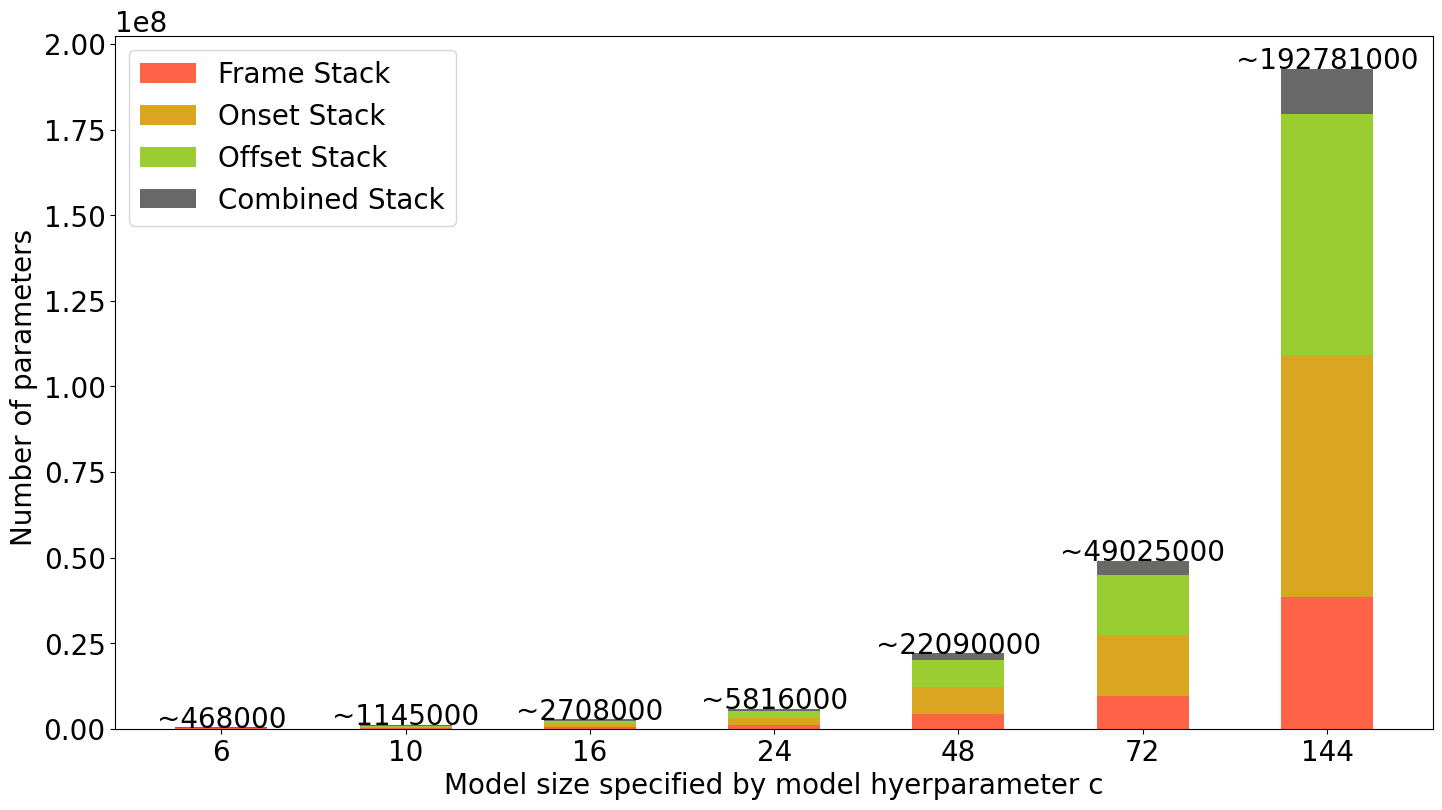

In [23]:
import matplotlib.pyplot as plt
import numpy as np
import copy
import matplotlib

def add_labels(x, y):
    for i in range(len(x)):
        plt.text(i, y[i], f'~{int(np.ceil(y[i] / 1000.0) * 1000)}', ha='center')



models = ('6', '10', '16', '24', '48', '72', '144')

plt.rcParams['axes.prop_cycle'] = plt.cycler(color=['tomato', 'goldenrod', 'yellowgreen', 'dimgrey', 'orchid', 'blue', 'red'])  # Blue, Orange, Green
matplotlib.rcParams.update({'font.size': 20})

width = 0.5
fig, ax = plt.subplots(figsize=(17, 9))
bottom: np.ndarray = np.zeros(7)

stack_sizes = {
    'Frame Stack': np.array(    [75394, 199638, 497064,    1100944,    4266480, 9699712,   38590504]), # how large is the frame stack in each model
    'Onset Stack': np.array(    [131458, 354518, 892328,    1988752,    7879240, 17671552,  70459432]),
    'Offset Stack': np.array(   [131458, 354518, 892328,   1988752,    7879240, 17671552,  70459432]),
    'Combined Stack': np.array( [129112, 235608, 426072, 737368,     2064472, 3981400,   13271128])
}

labels_x = models
labels_y = []
for i in range(len(labels_x)):
    sum = 0
    for stack in stack_sizes.keys():
        sum += stack_sizes[stack][i]
    labels_y.append(sum)

for stack, contribution in stack_sizes.items():
    p = ax.bar(models, contribution, width, label=stack, bottom=bottom)
    bottom += contribution

add_labels(labels_x, labels_y)

# ax.bar('M', 100, width, bottom=bottom, label='MuN')
plt.xlabel('Model size specified by model hyerparameter c')
plt.ylabel('Number of parameters ')
plt.legend()
plt.show()